# Neural Networks from Scratch (Intro to Gen AI, Lecture 1)

Companion notebook for `01-AI-ML-DL-Foundations.md` and `02-Neural-Networks-Fundamentals.md`. Only NumPy + scikit-learn are needed.

| Part | Topic |
|---|---|
| A | Supervised setup: empirical risk with squared loss |
| B | Activations & output units (sigmoid, tanh, ReLU, softmax) |
| C | Forward pass by hand: the slide's 2-2-1 network with numbers |
| D | XOR: linear models fail; a hand-built network solves it |
| E | **Train a neural network from scratch** (forward + backprop + gradient descent) |
| F | Why depth needs non-linearity: stacked linear layers collapse |
| G | Parameter counting for feed-forward networks |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## Part A — Learning = choosing h ∈ ℋ that minimises the loss

In [2]:
# Toy regression data drawn from an 'unknown' P(X, Y):  y = 3x + 2 + noise
x = rng.uniform(0, 5, 50); y = 3 * x + 2 + rng.normal(0, 1, 50)

def L_sq(h):                          # squared loss (slide 13): (1/n) Σ (h(x_i) − y_i)²
    return np.mean((h(x) - y) ** 2)

hypotheses = {                        # a tiny hypothesis class ℋ
    "h1(x) = 2x":       lambda x: 2 * x,
    "h2(x) = 3x":       lambda x: 3 * x,
    "h3(x) = 3x + 2":   lambda x: 3 * x + 2,
    "h4(x) = x² ":      lambda x: x ** 2,
}
for name, h in hypotheses.items():
    print(f"{name:18s} L_sq = {L_sq(h):8.3f}")
print("→ argmin over ℋ is h3, the one matching the true process")

h1(x) = 2x         L_sq =   25.369
h2(x) = 3x         L_sq =    5.151
h3(x) = 3x + 2     L_sq =    1.018
h4(x) = x²         L_sq =   12.790
→ argmin over ℋ is h3, the one matching the true process


## Part B — Activations and output units

In [3]:
sigmoid = lambda z: 1 / (1 + np.exp(-z))
relu    = lambda z: np.maximum(0, z)
def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)     # subtract max for numerical stability (doesn't change the result)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

z = np.array([-3., -1., 0., 1., 3.])
print("z       :", z)
print("sigmoid :", sigmoid(z))
print("tanh    :", np.tanh(z))
print("ReLU    :", relu(z))
logits = np.array([2.0, 1.0, 0.1])
print("\nsoftmax([2, 1, 0.1]) =", softmax(logits), " sum =", softmax(logits).sum())
print("softmax with a huge logit (stable):", softmax(np.array([1000., 999., 0.])))

z       : [-3. -1.  0.  1.  3.]
sigmoid : [0.0474 0.2689 0.5    0.7311 0.9526]
tanh    : [-0.9951 -0.7616  0.      0.7616  0.9951]
ReLU    : [0. 0. 0. 1. 3.]

softmax([2, 1, 0.1]) = [0.659  0.2424 0.0986]  sum = 1.0
softmax with a huge logit (stable): [0.7311 0.2689 0.    ]


In [4]:
# Sigmoid is the 2-class special case of softmax: softmax([z, 0])[0] == sigmoid(z)
for zz in [-2., 0., 1.5]:
    print(f"z={zz:+.1f}: softmax([z,0])[0]={softmax(np.array([zz, 0.]))[0]:.4f}   sigmoid(z)={sigmoid(zz):.4f}")
# tanh is a rescaled sigmoid: tanh(z) = 2σ(2z) − 1
print("max |tanh(z) − (2σ(2z) − 1)| =", np.abs(np.tanh(z) - (2 * sigmoid(2 * z) - 1)).max())

z=-2.0: softmax([z,0])[0]=0.1192   sigmoid(z)=0.1192
z=+0.0: softmax([z,0])[0]=0.5000   sigmoid(z)=0.5000
z=+1.5: softmax([z,0])[0]=0.8176   sigmoid(z)=0.8176
max |tanh(z) − (2σ(2z) − 1)| = 2.220446049250313e-16


## Part C — Forward pass by hand (the slide's network: 2 inputs → 2 hidden → 1 output)

In [5]:
x  = np.array([1.0, 2.0])                     # input
W1 = np.array([[0.5, -1.0],                   # row i = weights INTO hidden neuron i
               [1.5,  0.5]])
c1 = np.array([0.0, -1.0])                    # hidden biases
W2 = np.array([[2.0, -1.0]])                  # output weights
c2 = np.array([0.5])

a1 = W1 @ x + c1                              # pre-activation   a_i = Σ_j W_ij x_j + c_i
h1 = relu(a1)                                 # activation       h_i = g(a_i)
a2 = W2 @ h1 + c2                             # output pre-activation
y_hat = sigmoid(a2)                           # sigmoid output → P(y=1 | x)
print("a1 =", a1, " (0.5·1 − 1·2 + 0 = −1.5 ;  1.5·1 + 0.5·2 − 1 = 1.5)")
print("h1 = ReLU(a1) =", h1)
print("a2 =", a2, " (2·0 − 1·1.5 + 0.5 = −1.0)")
print("ŷ = σ(a2) =", y_hat.round(4))

a1 = [-1.5  1.5]  (0.5·1 − 1·2 + 0 = −1.5 ;  1.5·1 + 0.5·2 − 1 = 1.5)
h1 = ReLU(a1) = [0.  1.5]
a2 = [-1.]  (2·0 − 1·1.5 + 0.5 = −1.0)
ŷ = σ(a2) = [0.2689]


## Part D — XOR

In [6]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]); y = np.array([0, 1, 1, 0])

# 1) Any linear classifier fails: try a brute-force search over many lines w1·x1 + w2·x2 + b > 0
best = 0
for w1 in np.linspace(-2, 2, 41):
    for w2 in np.linspace(-2, 2, 41):
        for b in np.linspace(-2, 2, 41):
            best = max(best, np.mean(((X @ [w1, w2] + b) > 0).astype(int) == y))
print("best accuracy of ANY line (68,921 tried):", best, "→ at most 3 of 4 points")

best accuracy of ANY line (68,921 tried): 0.75 → at most 3 of 4 points


In [7]:
# 2) A hand-designed 2-2-1 network with step activations solves it exactly
step = lambda z: (z >= 0).astype(int)
W1 = np.array([[1, 1],     # h1 = OR  : x1 + x2 − 0.5 ≥ 0
               [1, 1]])    # h2 = AND : x1 + x2 − 1.5 ≥ 0
c1 = np.array([-0.5, -1.5])
W2 = np.array([1, -1]); c2 = -0.5            # y = h1 AND NOT h2 : h1 − h2 − 0.5 ≥ 0
H = step(X @ W1.T + c1)
print("x1 x2 | h1(OR) h2(AND) | ŷ  y")
for xi, hi, yi in zip(X, H, y):
    print(f" {xi[0]}  {xi[1]} |   {hi[0]}      {hi[1]}     | {step(hi @ W2 + c2)}  {yi}")
print("\nHidden representation: (0,0)→", H[0], " (0,1)→", H[1], " (1,0)→", H[2], " (1,1)→", H[3])
print("In (h1, h2) space the classes ARE linearly separable: the hidden layer changed the representation.")

x1 x2 | h1(OR) h2(AND) | ŷ  y
 0  0 |   0      0     | 0  0
 0  1 |   1      0     | 1  1
 1  0 |   1      0     | 1  1
 1  1 |   1      1     | 0  0

Hidden representation: (0,0)→ [0 0]  (0,1)→ [1 0]  (1,0)→ [1 0]  (1,1)→ [1 1]
In (h1, h2) space the classes ARE linearly separable: the hidden layer changed the representation.


## Part E — Train a neural network from scratch
Architecture: 2 → 4 (tanh) → 1 (sigmoid), binary cross-entropy loss, full-batch gradient descent. Backprop is just the chain rule (lecture coming up); every gradient line is commented.

final loss: 0.00047
P(y=1|x): [0.    0.999 0.999 0.001] → predictions [0 1 1 0]  targets [0 1 1 0]


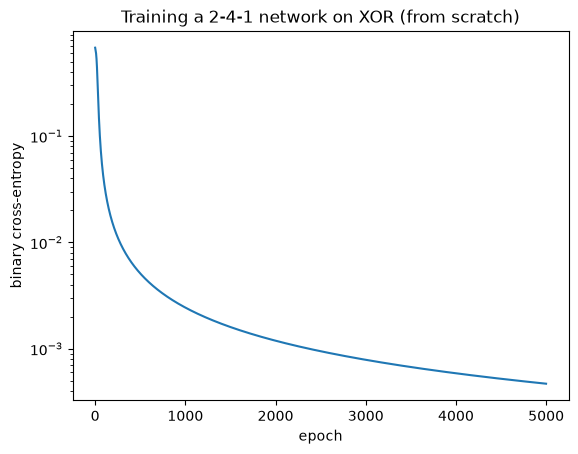

In [8]:
def train_xor(hidden=4, lr=1.0, epochs=5000, seed=1):
    r = np.random.default_rng(seed)
    W1 = r.normal(0, 1, (hidden, 2)); b1 = np.zeros(hidden)
    W2 = r.normal(0, 1, (1, hidden)); b2 = np.zeros(1)
    Xf, yf = X.astype(float), y.astype(float).reshape(-1, 1)
    losses = []
    for _ in range(epochs):
        # ---- forward pass ----
        A1 = Xf @ W1.T + b1            # (4, hidden) pre-activations
        H1 = np.tanh(A1)               # (4, hidden) activations
        A2 = H1 @ W2.T + b2            # (4, 1)
        P  = sigmoid(A2)               # (4, 1) predicted P(y=1|x)
        loss = -np.mean(yf * np.log(P + 1e-12) + (1 - yf) * np.log(1 - P + 1e-12))
        losses.append(loss)
        # ---- backward pass (chain rule) ----
        dA2 = (P - yf) / len(Xf)       # d loss / d A2  (sigmoid + BCE simplify to P − y)
        dW2 = dA2.T @ H1;  db2 = dA2.sum(0)
        dH1 = dA2 @ W2                 # back through the output weights
        dA1 = dH1 * (1 - H1 ** 2)      # back through tanh: tanh' = 1 − tanh²
        dW1 = dA1.T @ Xf;  db1 = dA1.sum(0)
        # ---- gradient descent step ----
        W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2
    return (W1, b1, W2, b2), losses, P.ravel()

params, losses, P = train_xor()
print("final loss:", round(losses[-1], 5))
print("P(y=1|x):", P.round(3), "→ predictions", (P > 0.5).astype(int), " targets", y)
plt.plot(losses); plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("binary cross-entropy")
plt.title("Training a 2-4-1 network on XOR (from scratch)"); plt.show()

In [9]:
# Sanity-check backprop with numerical gradients (the standard debugging trick)
def loss_given(W1, b1, W2, b2):
    P = sigmoid(np.tanh(X @ W1.T + b1) @ W2.T + b2)
    yf = y.reshape(-1, 1)
    return -np.mean(yf * np.log(P) + (1 - yf) * np.log(1 - P))

r = np.random.default_rng(3)
W1, b1, W2, b2 = r.normal(size=(3, 2)), r.normal(size=3), r.normal(size=(1, 3)), r.normal(size=1)
# analytic gradient for W1[0,0] via the same formulas as above
H1 = np.tanh(X @ W1.T + b1); P = sigmoid(H1 @ W2.T + b2)
dA1 = (((P - y.reshape(-1, 1)) / 4) @ W2) * (1 - H1 ** 2)
analytic = (dA1.T @ X)[0, 0]
eps = 1e-6; Wp, Wm = W1.copy(), W1.copy(); Wp[0, 0] += eps; Wm[0, 0] -= eps
numeric = (loss_given(Wp, b1, W2, b2) - loss_given(Wm, b1, W2, b2)) / (2 * eps)
print(f"analytic {analytic:.8f}  numeric {numeric:.8f}  → match: {np.isclose(analytic, numeric)}")

analytic -0.38643399  numeric -0.38643399  → match: True


In [10]:
# Same thing with scikit-learn, on a noisy XOR-like dataset
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
Xd = rng.uniform(-1, 1, (400, 2)); yd = ((Xd[:, 0] > 0) ^ (Xd[:, 1] > 0)).astype(int)
for name, m in [("LogisticRegression", LogisticRegression()),
                ("MLP identity act.", MLPClassifier((8,), activation="identity", max_iter=3000, random_state=0)),
                ("MLP ReLU", MLPClassifier((8,), activation="relu", max_iter=3000, random_state=0))]:
    print(f"{name:20s} train accuracy = {m.fit(Xd, yd).score(Xd, yd):.3f}")

LogisticRegression   train accuracy = 0.522
MLP identity act.    train accuracy = 0.537


MLP ReLU             train accuracy = 0.985


## Part F — Without non-linearity, depth is useless

In [11]:
W1, b1 = rng.normal(size=(5, 3)), rng.normal(size=5)
W2, b2 = rng.normal(size=(4, 5)), rng.normal(size=4)
W3, b3 = rng.normal(size=(2, 4)), rng.normal(size=2)
xin = rng.normal(size=3)
deep_linear = W3 @ (W2 @ (W1 @ xin + b1) + b2) + b3            # 3 'layers', no activation
W, b = W3 @ W2 @ W1, W3 @ (W2 @ b1 + b2) + b3                 # one equivalent layer
print("3 linear layers :", deep_linear)
print("1 linear layer  :", W @ xin + b, "→ identical. Stacking linear layers = one linear layer.")

3 linear layers : [4.287  3.4119]
1 linear layer  : [4.287  3.4119] → identical. Stacking linear layers = one linear layer.


## Part G — Counting parameters θ

In [12]:
def count_params(sizes):
    """sizes = [input, hidden1, ..., output]. Each layer: weights (out×in) + biases (out)."""
    total = 0
    for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:]), 1):
        p = n_in * n_out + n_out
        print(f"  layer {i}: W {n_out}×{n_in} + b {n_out} = {p:,}")
        total += p
    return total

for sizes in [[2, 2, 1], [2, 4, 1], [784, 128, 64, 10]]:
    print(sizes); print("  total θ =", f"{count_params(sizes):,}")
print("\nFor scale: GPT-3 has 175,000,000,000 parameters; same idea, many more (and wider) layers.")

[2, 2, 1]
  layer 1: W 2×2 + b 2 = 6
  layer 2: W 1×2 + b 1 = 3
  total θ = 9
[2, 4, 1]
  layer 1: W 4×2 + b 4 = 12
  layer 2: W 1×4 + b 1 = 5
  total θ = 17
[784, 128, 64, 10]
  layer 1: W 128×784 + b 128 = 100,480
  layer 2: W 64×128 + b 64 = 8,256
  layer 3: W 10×64 + b 10 = 650
  total θ = 109,386

For scale: GPT-3 has 175,000,000,000 parameters; same idea, many more (and wider) layers.
